<a href="https://colab.research.google.com/github/BallFord/BigData26_A_2411531004_IqbalMiftahulFikri/blob/main/Praktikum%2001/BD_A_P01_2411531004_IqbalMiftahulFikri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **J-1. Verifikasi lingkungan kerja**
### Kode ini berfungsi untuk mengecek dan mendokumentasikan lingkungan kerja Google Colab. Skrip mendeteksi versi Python, sistem operasi, jumlah core CPU, serta versi pustaka utama (pandas, numpy, pyarrow, matplotlib), lalu mengeksekusi perintah shell untuk mengukur sisa RAM, kapasitas disk, dan ketersediaan Java.

In [ ]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

!free -h           # kapasitas dan sisa RAM
!df -h /content    # kapasitas dan sisa disk runtime
!java -version     # dibutuhkan PySpark pada langkah K-8

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.35
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 18.1.0
matplotlib : 3.10.0
               total        used        free      shared  buff/cache   available
Mem:            12Gi       688Mi       8.8Gi       2.0Mi       3.2Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.024s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.024s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.11" 2026-04-21
OpenJDK Runtime Environment (build 21.0.11+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.11+10-1-22.04.2-Ubuntu, mixed mode, sharing)


# **J-2. Menghubungkan Google Drive dan menyiapkan struktur folder**
### Kode ini berfungsi untuk menghubungkan Google Drive ke runtime Google Colab. Selanjutnya, skrip mendefinisikan dan membuat dua direktori menggunakan pustaka os, yaitu folder kerja sementara di lokal Colab (DIR_KERJA) untuk proses yang membutuhkan I/O cepat, serta folder penyimpanan di Google Drive (DIR_SIMPAN), lalu menampilkan daftar berkas yang sudah ada di dalam folder penyimpanan tersebut.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA  = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png', 'studi_kasus_permintaan.png', 'studi_kasus_profitabilitas.png']


# **J-3. Menyiapkan alat ukur waktu dan memori**
### Kode ini menyiapkan fungsi pembantu untuk mengukur kinerja eksekusi kode dari segi waktu dan konsumsi memori. Fungsi rss_mb() membaca memori fisik nyata yang digunakan oleh proses Python. Sementara itu, fungsi ukur() menerima sebuah fungsi lain sebagai parameter, menghitung durasi jalannya fungsi tersebut beserta perubahan penggunaan memori, mencatat hasilnya ke dalam daftar catatan, lalu menampilkan ringkasannya ke layar.

In [ ]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

# **J-4. Mengunduh dataset dan inspeksi awal**
### Kode ini mengunduh dataset perjalanan taksi NYC TLC ke direktori kerja jika berkas belum ada, sekaligus mengukur durasi dan penggunaan memori saat proses pengunduhan. Setelah itu, skrip memeriksa ukuran berkas dan menggunakan pustaka pyarrow untuk membaca metadata berkas Parquet tersebut, jumlah kolom, row group, dan nama-nama kolom—tanpa perlu memuat isi seluruh datanya ke dalam memori.

In [ ]:
import urllib.request
import pyarrow.parquet as pq

# 1. Mengunduh dataset
URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

# 2. Inspeksi metadata parquet
meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

[unduh dataset] 2.25 s | RSS +1.1 MB
Ukuran file: 45.5 MB
Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


# **J-5. Memuat data dan mengukur biaya memorinya**
### Kode ini membandingkan penggunaan memori antara memuat seluruh kolom dataset dengan memuat kolom pilihan saja untuk membuktikan efisiensi format Parquet. Setelah membebaskan memori variabel awal dengan del dan gc.collect(), skrip mengukur penggunaan memori tiap kolom dan melakukan optimasi tipe data (downcasting numerik serta konversi ke category), lalu menghitung persentase total memori yang berhasil dihemat.

In [ ]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 1.28 s | RSS +499.2 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.36 s | RSS +221.1 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [ ]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [ ]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]   = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


# **J-6. Pemeriksaan kualitas data dan pembersihan (veracity)**
### Kode ini berfungsi untuk memeriksa kualitas data dan melakukan pembersihan. Di bagian awal, skrip menghitung durasi perjalanan dalam satuan menit dari selisih waktu penjemputan dan penurunan, lalu menampilkan statistik deskriptif serta jumlah nilai kosong pada tiap kolom. Selanjutnya, kode mendeteksi baris anomali, seperti jarak atau durasi <= 0, durasi di atas 180 menit, dan tarif <= 0, kemudian menyaring hanya data yang layak analisis ke dalam DataFrame baru bernama bersih serta menampilkan jumlah baris yang berhasil dibuang.

In [ ]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"          : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"         : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit" : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"  : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [ ]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


# **J-7. Memproses file lebih besar dari memori dengan chunking**
### Kode ini mensimulasikan pemrosesan data out of core ketika ukuran file melebihi kapasitas memori. Pertama, data bersih diekspor ke format CSV teks untuk membandingkan ukurannya dengan Parquet yang jauh lebih terkompresi. Selanjutnya, fungsi agregasi_bertahap membaca berkas CSV tersebut secara bertahap sebanyak 500.000 baris per iterasi, lalu menghitung total transaksi dan agregasi perjalanan per jam di setiap potongan data tanpa memuat seluruh isi berkas ke memori sekaligus.

In [ ]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 20.87 s | RSS +5.3 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 3.38 s | RSS +20.0 MB
2,986,911 baris | rata-rata total_amount = 27.33


# **J-8. Pendekatan terdistribusi: PySpark local mode**
### Kode ini mengimplementasikan pemrosesan data terdistribusi menggunakan PySpark mode lokal. Skrip dimulai dengan menginstal PySpark 3.5.1 dan membangkitkan SparkSession yang memanfaatkan seluruh core CPU. Setelah data Parquet dimuat dan dibersihkan dari anomali, PySpark melakukan agregasi perjalanan per jam serta kueri Spark SQL untuk melihat ringkasan berdasarkan metode pembayaran. Di akhir sel, fungsi explain() digunakan untuk melihat rencana eksekusi kueri, lalu sesi Spark dihentikan dengan spark.stop() untuk membebaskan sumber daya runtime.

In [ ]:
!pip install -q pyspark==3.5.1
!java -version

from pyspark.sql import SparkSession, functions as F

# Membuat sesi Spark lokal
spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

# Memuat data dan inspeksi awal
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

# Pembersihan data (veracity)
sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("timestamp").cast("long")
        - F.col("tpep_pickup_datetime").cast("timestamp").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

# Agregasi data per jam
hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

# Kueri Spark SQL
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                    AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 8.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.027s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.027s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.11" 2026-04-21
OpenJDK Runtime Environment (build 21.0.11+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.11+10-1-22.04.2-Ubuntu, mixed mode, sharing

# **J-9. Agregasi akhir dengan pandas dan penyimpanan artefak**
### Kode ini melakukan agregasi akhir menggunakan pandas dan menyimpan artefak hasil praktikum ke Google Drive. Skrip membuat kolom jam dari waktu penjemputan untuk menghitung statistik perjalanan per jam, mencakup total perjalanan, rata-rata jarak, durasi, tarif, serta median tarif. Hasil agregasi tersebut kemudian disimpan dalam format CSV dan Parquet bersama dengan riwayat log pengukuran performa agar data tersimpan aman dari runtime yang bersifat sementara, lalu diakhiri dengan menampilkan ringkasan tabel agregasi di layar notebook.

In [ ]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


# **J-10. Visualisasi hasil**
### Kode ini berfungsi untuk memvisualisasikan hasil agregasi perjalanan taksi ke dalam bentuk diagram batang menggunakan pustaka matplotlib. Skrip membuat grafik yang menampilkan distribusi total perjalanan berdasarkan jam penjemputan (0–23), melengkapinya dengan label sumbu serta judul yang jelas, menyimpan gambar grafik beresolusi 150 DPI ke folder Google Drive, dan menampilkan grafik tersebut di layar notebook.

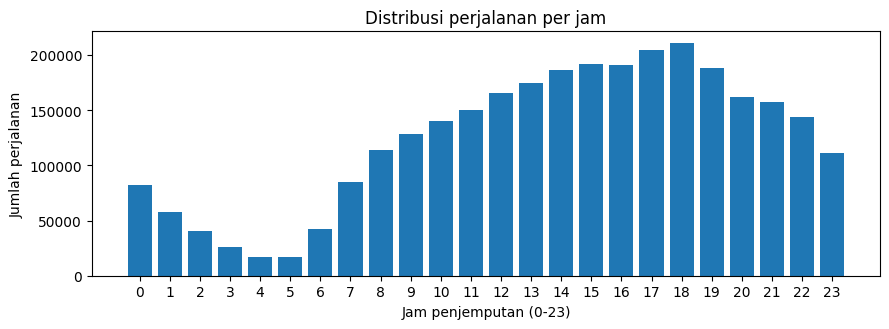

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

# **Studi Kasus**
### Kasus: penjadwalan armada oleh operator taksi
Sebuah operator memiliki 1.200 armada dan ingin menyusun jadwal shift pengemudi untuk kuartal
berikutnya. Manajemen operasional meminta jawaban atas tiga pertanyaan: (1) pada jam berapa
permintaan tertinggi dan terendah; (2) apakah pola tersebut berbeda antara hari kerja dan akhir
pekan; (3) apakah perjalanan pada jam sibuk lebih pendek namun lebih menguntungkan per menit
dibanding jam lain. Tim data Anda hanya diberi waktu satu hari kerja dan satu mesin — tanpa klaster.

--- 12 Baris Pertama Tabel Agregasi ---


,akhir_pekan,jam,jumlah,rata_durasi,rata_tarif_per_menit
0,False,0,35351,14.10,2.57
1,False,1,17516,13.04,2.66
2,False,2,9452,12.23,2.63
3,False,3,6238,12.87,2.72
4,False,4,6192,14.79,2.81
5,False,5,12462,14.63,2.82
6,False,6,35728,14.57,2.33
7,False,7,74157,14.66,2.07
8,False,8,98431,14.82,1.90
9,False,9,103263,15.03,1.90


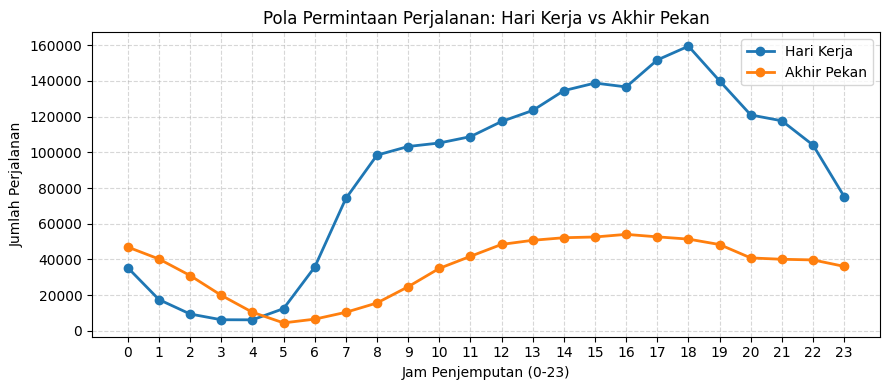

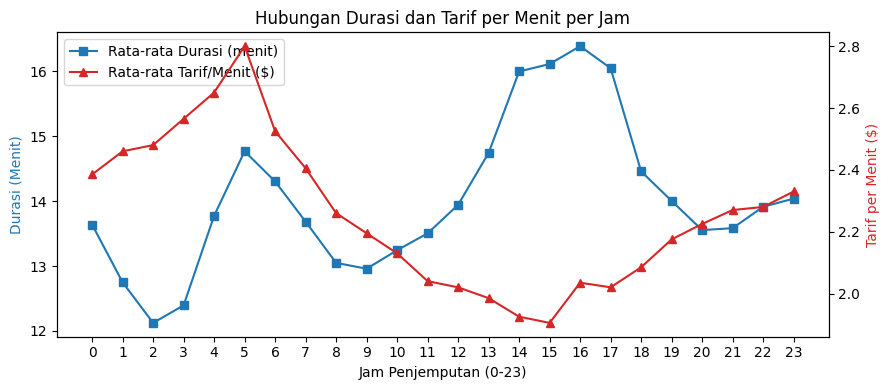

In [ ]:
import matplotlib.pyplot as plt

# 1. Feature Engineering (Menambahkan Dimensi Baru)
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

# 2. Agregasi Data per Hari Kerja vs Akhir Pekan dan Jam
ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

print("--- 12 Baris Pertama Tabel Agregasi ---")
display(ringkas.head(12))

# 3. Grafik 1: Distribusi Permintaan Perjalanan (Hari Kerja vs Akhir Pekan)
plt.figure(figsize=(9, 4))
for is_weekend, df_group in ringkas.groupby("akhir_pekan"):
    label = "Akhir Pekan" if is_weekend else "Hari Kerja"
    plt.plot(df_group["jam"], df_group["jumlah"], marker='o', linewidth=2, label=label)

plt.xlabel("Jam Penjemputan (0-23)")
plt.ylabel("Jumlah Perjalanan")
plt.title("Pola Permintaan Perjalanan: Hari Kerja vs Akhir Pekan")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/studi_kasus_permintaan.png", dpi=150)
plt.show()

# 4. Grafik 2: Profil Profitabilitas (Tarif per Menit) dan Durasi Perjalanan per Jam
ringkas_jam = ringkas.groupby("jam").agg(
    rata_durasi=("rata_durasi", "mean"),
    rata_tarif_per_menit=("rata_tarif_per_menit", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

line1 = ax1.plot(ringkas_jam["jam"], ringkas_jam["rata_durasi"], color='tab:blue', marker='s', label='Rata-rata Durasi (menit)')
line2 = ax2.plot(ringkas_jam["jam"], ringkas_jam["rata_tarif_per_menit"], color='tab:red', marker='^', label='Rata-rata Tarif/Menit ($)')

ax1.set_xlabel("Jam Penjemputan (0-23)")
ax1.set_ylabel("Durasi (Menit)", color='tab:blue')
ax2.set_ylabel("Tarif per Menit ($)", color='tab:red')
plt.title("Hubungan Durasi dan Tarif per Menit per Jam")
ax1.set_xticks(range(0, 24))

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/studi_kasus_profitabilitas.png", dpi=150)
plt.show()

# **Latihan**

## **Latihan 1: 5 Nilai trip_distance Terbesar**
### Kode ini memanfaatkan fungsi .nlargest() untuk mencari dan menampilkan lima baris data dengan jarak perjalanan terjauh dari DataFrame bersih. Penjelasan ini membuktikan bahwa data perjalanan dengan jarak di atas 90 mil masih masuk akal sebagai perjalanan luar kota dan valid karena nilainya masih berada di bawah ambang batas penyaringan 100 mil.

In [ ]:
top5_jarak = bersih.nlargest(5, "trip_distance")
display(top5_jarak)

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


## **Latihan 2: Pengujian Chunksize 100.000 vs 1.000.000**
### Kode ini menjalankan ulang fungsi pemrosesan bertahap menggunakan dua variasi ukuran potongan data yang berbeda untuk membandingkan konsumsi waktu dan pemakaian memori (RSS). Hasilnya memperlihatkan bentuk trade off, di mana chunksize lebih kecil (100.000) menjaga penggunaan RAM tetap hemat namun butuh waktu I/O sedikit lebih lama, sedangkan chunksize lebih besar (1.000.000) memproses data lebih cepat dengan konsekuensi memakan RAM lebih banyak per potongannya.

In [ ]:
print("--- Chunksize = 100,000 ---")
ukur("chunking 100k", lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000))

print("\n--- Chunksize = 1,000,000 ---")
ukur("chunking 1M", lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000))

--- Chunksize = 100,000 ---
[chunking 100k] 3.57 s | RSS +52.5 MB

--- Chunksize = 1,000,000 ---
[chunking 1M] 2.43 s | RSS +82.1 MB


(2986911,
 np.float64(81621456.73999998),
 {0: (82289, np.float64(2374799.56)),
  1: (57766, np.float64(1527804.7999999998)),
  2: (40445, np.float64(1013644.6699999999)),
  3: (26146, np.float64(686565.89)),
  4: (16618, np.float64(527193.1399999999)),
  5: (16940, np.float64(622535.48)),
  6: (42300, np.float64(1295568.83)),
  7: (84569, np.float64(2273795.19)),
  8: (114064, np.float64(2875425.58)),
  9: (127988, np.float64(3264835.5)),
  10: (140230, np.float64(3580659.3200000003)),
  11: (150539, np.float64(3787918.5200000005)),
  12: (165714, np.float64(4243586.279999999)),
  13: (174183, np.float64(4604514.72)),
  14: (186741, np.float64(5236230.47)),
  15: (191392, np.float64(5248916.31)),
  16: (190689, np.float64(5641460.04)),
  17: (204399, np.float64(5850060.35)),
  18: (210858, np.float64(5628483.38)),
  19: (188347, np.float64(5167225.42)),
  20: (161789, np.float64(4365741.890000001)),
  21: (157770, np.float64(4353317.59)),
  22: (143800, np.float64(4113658.3399999994))

## **Latihan 3: Rata-Rata Persen Tip per Metode Pembayaran**
## Kode ini menghitung persentase tip terhadap tarif dasar menggunakan np.where() untuk menghindari kesalahan pembagian dengan nol ketika nilai fare_amount bernilai 0, lalu mengelompokkan rata-ratanya berdasarkan metode pembayaran. Analisis ini menunjukkan bahwa transaksi kartu kredit secara otomatis mencatat persentase tip yang tinggi pada sistem digital, sementara pembayaran tunai mencatatkan angka tip mendekati nol pada data karena tip diberikan secara langsung kepada pengemudi tanpa terdata oleh sistem.

In [ ]:
import numpy as np

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] > 0,
    (bersih["tip_amount"] / bersih["fare_amount"]) * 100,
    0.0
)

rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2).reset_index()
display(rata_tip)

/tmp/ipykernel_3359/4157987808.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2).reset_index()


,payment_type,persen_tip
0,0,20.23
1,1,25.91
2,2,0.00
3,3,0.02
4,4,0.15


## **Latihan 4: Kompresi Parquet (Snappy vs Gzip)**
### Kode ini mengekspor DataFrame bersih ke dalam dua berkas Parquet berbeda menggunakan algoritma kompresi snappy dan gzip untuk membandingkan durasi penulisan serta ukuran berkas akhirnya. Pengujian membuktikan bahwa gzip menghasilkan ukuran file yang lebih kecil karena tingkat kompresinya lebih padat namun membutuhkan waktu CPU lebih lama, sedangkan snappy mendapatkan kecepatan penulisan yang jauh lebih tinggi dengan mengorbankan sedikit ukuran berkas.

In [ ]:
PATH_SNAPPY = os.path.join(DIR_KERJA, "trips_snappy.parquet")
PATH_GZIP   = os.path.join(DIR_KERJA, "trips_gzip.parquet")

ukur("tulis Parquet Snappy", lambda: bersih.to_parquet(PATH_SNAPPY, compression="snappy", index=False))
ukur("tulis Parquet Gzip",   lambda: bersih.to_parquet(PATH_GZIP,   compression="gzip",   index=False))

size_snappy = round(os.path.getsize(PATH_SNAPPY) / 1024**2, 2)
size_gzip   = round(os.path.getsize(PATH_GZIP) / 1024**2, 2)

print(f"Ukuran File Snappy : {size_snappy} MB")
print(f"Ukuran File Gzip   : {size_gzip} MB")

[tulis Parquet Snappy] 1.12 s | RSS +7.8 MB
[tulis Parquet Gzip] 7.15 s | RSS -13.8 MB
Ukuran File Snappy : 63.88 MB
Ukuran File Gzip   : 51.4 MB


## **Latihan 5: Agregasi per Jam dengan Spark SQL & Verifikasi Konsistensi**
### Kode ini mengonversi DataFrame pandas ke bentuk PySpark, mendaftarkannya sebagai tabel temporer, lalu mengeksekusi kueri agregasi jumlah perjalanan per jam menggunakan perintah Spark SQL. Hasil akhir dari Spark SQL kemudian dibandingkan secara terprogram dengan hasil agregasi pandas untuk membuktikan bahwa selisih maksimum keduanya bernilai 0, yang berarti bahwa logika perhitungan pada kedua alat komputasi tersebut konsisten secara mutlak.

In [ ]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
    .appName("Latihan5")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

# Membaca file parquet bersih langsung dari pandas/parquet
sdf_lat5 = spark.createDataFrame(bersih)
sdf_lat5.createOrReplaceTempView("trips_bersih")

# Agregasi jam menggunakan Spark SQL
agregasi_spark_sql = spark.sql("""
    SELECT jam, COUNT(*) AS jumlah_perjalanan
    FROM trips_bersih
    GROUP BY jam
    ORDER BY jam
""").toPandas()

# Verifikasi konsistensi selisih maksimum
selisih_maks = (agregasi["jumlah_perjalanan"] - agregasi_spark_sql["jumlah_perjalanan"]).abs().max()
print("Selisih maksimum jumlah perjalanan (pandas vs Spark SQL):", selisih_maks)

spark.stop()

Selisih maksimum jumlah perjalanan (pandas vs Spark SQL): 0
